### Install required libraries

Using torchaudio==2.8 here as 2.9 forces the use of torchcodec:

In [1]:
%pip install pandas numpy matplotlib torch torchaudio==2.8 soundfile


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Imports

In [2]:
from IPython.display import Audio

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch, torchaudio
import torch.nn as nn

from torch import Tensor
from torch.utils.data import Dataset
from tqdm import tqdm

### Constants

In [3]:
INPUT_DIR = 'input'

# Hyperparameters
ORIGINAL_SAMPLE_RATE = 48_000
TARGET_SAMPLE_RATE = 16_000
TARGET_AUDIO_LENGTH = 0.84
TARGET_SAMPLES = int(TARGET_SAMPLE_RATE * TARGET_AUDIO_LENGTH)

N_MELS = 64

### Setting up device to use

In [4]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Defining the preprocessing pipeline for an audio file

In [5]:
class FixAudioLength(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, waveform: Tensor) -> Tensor:
        num_samples = waveform.shape[1]

        if num_samples > TARGET_SAMPLES:
            waveform = waveform[:, :TARGET_SAMPLES]
        elif num_samples < TARGET_SAMPLE_RATE:
            padding_needed = TARGET_SAMPLES - num_samples
            waveform = nn.functional.pad(waveform, (0, padding_needed))

        return waveform

def get_transformation_pipeline() -> nn.Module:
    """
    1. Resamples the waveform to 16,000 Hz
    2. Fixes the audio duration by truncating / padding
    3. Converts to a Mel Spectrogram
    4. Performs log-scaling by dB
    """
    return nn.Sequential(
        torchaudio.transforms.Resample(
            orig_freq=ORIGINAL_SAMPLE_RATE,
            new_freq=TARGET_SAMPLE_RATE),
        FixAudioLength(),
        torchaudio.transforms.MelSpectrogram(
            sample_rate=TARGET_SAMPLE_RATE,
            n_fft=1024,
            win_length=1024,
            hop_length=512,
            n_mels=N_MELS,
            power=2.0,
            pad_mode='constant',
            norm='slaney',
            mel_scale='slaney'
        ),
        torchaudio.transforms.AmplitudeToDB()
    )

pipeline = get_transformation_pipeline()

### Visualising audio data

Old samples: 36838
Old duration: 0.77
New samples: 13440
New duration: 0.84s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


NameError: name 'duration' is not defined

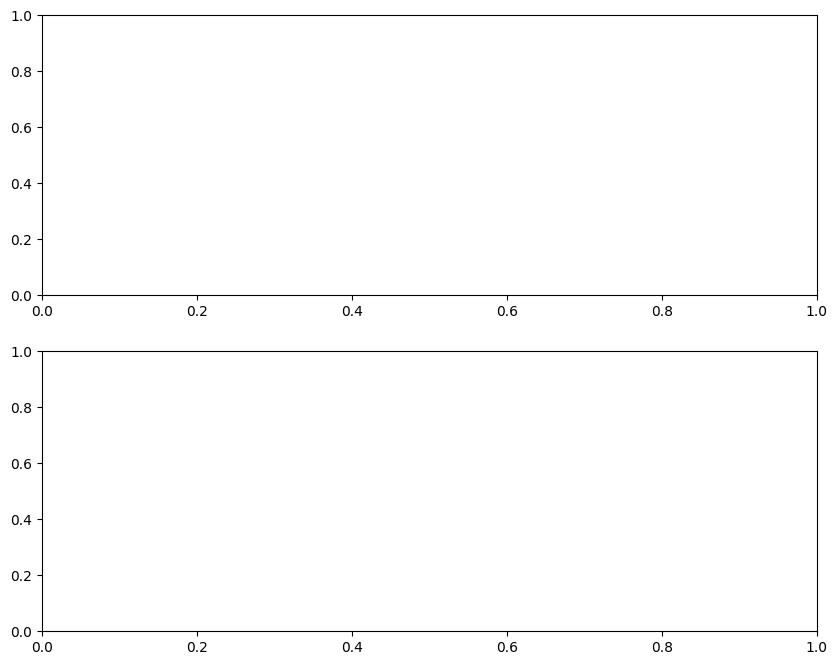

In [6]:
def visualise_audio_data() -> None:
    resampler = torchaudio.transforms.Resample(
        orig_freq=ORIGINAL_SAMPLE_RATE,
        new_freq=TARGET_SAMPLE_RATE
    )

    for i in range(3):
        # Randomly select a digit, speaker and sample
        digit = np.random.randint(0, 10)
        speaker = np.random.randint(1, 61)
        sample = np.random.randint(0, 50)

        if speaker < 10:
            file = f'{INPUT_DIR}/0{speaker}/{digit}_0{speaker}_{sample}.wav'
        else:
            file = f'{INPUT_DIR}/{speaker}/{digit}_{speaker}_{sample}.wav'

        # Do the resampling + audio length fixing here so we have access to the modified waveform
        waveform, sample_rate = torchaudio.load(file, normalize=True)
        old_samples = waveform.shape[1]
        old_duration = waveform.shape[1] / sample_rate

        new_waveform = FixAudioLength()(resampler(waveform))
        new_sample_rate = TARGET_SAMPLE_RATE
        new_samples = new_waveform.shape[1]
        new_duration = new_waveform.shape[1] / new_sample_rate

        mel_spectrogram = pipeline(waveform)

        print(f'Old samples: {old_samples}')
        print(f'Old duration: {old_duration:.2f}')
        print(f'New samples: {new_samples}')
        print(f'New duration: {new_duration:.2f}s')

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

        # Waveform
        ax1.plot(np.linspace(0, duration, waveform.shape[1]), waveform.t().numpy())
        ax1.set_xlim(0, duration)
        ax1.set_title(file)
        ax1.set_ylabel('Amplitude')

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, duration, 0, N_MELS],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=waveform, rate=sample_rate))

visualise_audio_data()

### Determining the 95th percentile for audio lengths

  0%|          | 0/30000 [00:00<?, ?it/s]/var/folders/m2/zhj6zm9x5b93941_pktttl300000gn/T/ipykernel_25916/4045780167.py:6: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info(file)
  2%|▏         | 457/30000 [00:00<00:06, 4563.89it/s]

48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
4800

  5%|▍         | 1406/30000 [00:00<00:06, 4518.57it/s]

48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
4800

  8%|▊         | 2407/30000 [00:00<00:05, 4825.74it/s]

...

48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
4800

 98%|█████████▊| 29257/30000 [00:05<00:00, 5119.90it/s]

48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
4800

100%|██████████| 30000/30000 [00:05<00:00, 5022.14it/s]


48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
48000
4800

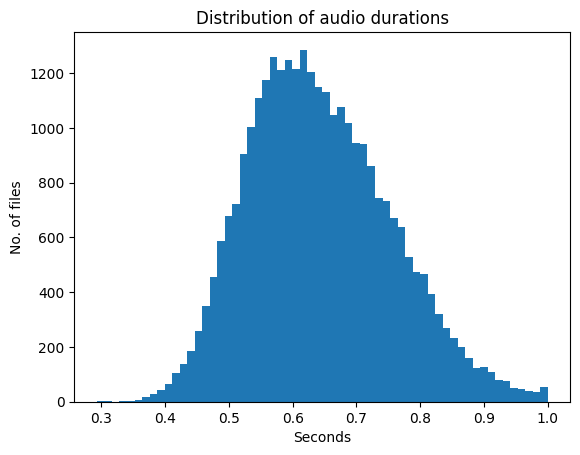

95% percentile: 0.84s


In [24]:
# Need this to be able to determine the best time to truncate / pad to
audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

durations = []
for file in tqdm(audio_files):
    info = torchaudio.info(file)
    duration = info.num_frames / info.sample_rate
    durations.append(duration)
    print(info.sample_rate)

durations = np.array(durations)

plt.hist(durations, bins=60)
plt.title('Distribution of audio durations')
plt.xlabel('Seconds')
plt.ylabel('No. of files')
plt.show()

print(f'95% percentile: {np.percentile(durations, 95):.2f}s')

### Custom DataSet for audio data

In [16]:
# TODO: Padding / truncation
class AudioDataset(Dataset):
    def __init__(self, transformation_pipeline: nn.Module):
        self.transformation_pipeline = transformation_pipeline
        self.audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

        self.labels = []
        for file in self.audio_files:
            filename = os.path.basename(file)
            label = int(filename.split('_')[0])
            self.labels.append(label)

    def __len__(self) -> int:
        return len(self.audio_files)

    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        audio_file = self.audio_files[index]
        label = self.labels[index]

        waveform, sample_rate = torchaudio.load(audio_file, normalize=True)

        # Truncate / pad audio lengths


        # Convert to Mel Spectrogram
        mel_spectrogram = self.transformation_pipeline(waveform)
        return mel_spectrogram, torch.tensor(label, dtype=torch.long)

7
7
2
3
9
9
3
4
4
1
2
2
9
8
8
5
5
8
9
8
2
2
1
4
4
3
9
9
3
7
2
7
3
2
7
9
7
6
9
3
4
4
1
1
6
2
2
8
2
8
9
5
5
8
2
9
8
2
2
6
1
1
4
4
3
9
6
9
7
2
7
3
3
7
2
9
3
9
9
4
4
1
1
8
9
8
2
2
5
5
2
2
9
8
8
1
1
4
4
9
9
3
9
7
2
3
0
2
7
3
7
3
9
9
4
4
4
1
8
9
8
2
2
5
5
2
2
8
8
9
1
4
4
4
9
9
3
7
3
2
7
0
0
9
3
3
4
5
4
6
6
2
8
8
5
5
5
5
8
8
2
6
6
4
5
4
3
3
9
0
0
0
7
9
3
3
3
5
4
4
6
2
8
8
5
5
5
5
8
8
2
6
4
4
5
3
3
3
9
7
0
0
0
0
3
3
9
4
5
4
6
8
8
2
8
5
5
5
5
8
2
8
8
6
4
5
4
9
3
3
0
0
0
0
1
3
3
9
4
4
5
1
6
6
8
8
2
5
5
5
5
5
5
2
8
8
6
6
1
5
4
4
9
3
3
1
0
0
1
0
0
0
7
3
9
1
6
6
8
5
5
5
5
8
6
6
1
9
3
7
0
0
0
1
0
0
1
0
0
7
3
3
4
1
6
6
8
8
5
5
8
8
6
6
1
4
3
3
7
0
0
1
0
0
0
0
0
1
7
3
3
4
5
1
6
6
8
8
5
5
8
8
6
6
1
5
4
3
3
7
1
0
0
0
0
0
1
0
7
3
1
6
6
6
8
2
5
5
5
5
2
8
6
6
6
1
3
7
0
1
0
0
0
3
2
7
7
9
7
6
4
4
1
1
6
8
2
2
8
6
1
1
4
4
6
7
9
7
7
2
3
0
0
7
7
9
9
6
7
4
1
1
1
6
9
2
8
2
5
5
2
8
9
2
6
1
1
1
4
7
6
9
9
7
7
0
0
7
7
6
9
7
9
4
1
1
6
2
2
2
2
6
1
1
4
9
9
7
6
7
7
0
0
7
7
7
7
6
3
9
4
4
1
1
6
2
2
6
1
1
4
4
9
3
6
7
7
7
7
0
